<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B9_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: Описательная статистика и анализ распределений в Python

[Ссылка](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset) на данные.

## 📊 Описание датасета

В данном задании используется датасет Sleep Health and Lifestyle Dataset, содержащий информацию о сне, образе жизни и здоровье людей.  
Датасет включает 374 наблюдения (строки) и 13 признаков (столбцов).  
Каждая строка соответствует одному человеку и содержит данные о его привычках, уровне активности, состоянии здоровья и качестве сна.  

📌 Данные являются синтетическими (созданы искусственно), но хорошо подходят для обучения анализу данных.

**Ключевые особенности датасета:**
- **Метрики сна:** позволяют анализировать продолжительность и качество сна, а также факторы, влияющие на него.     
- **Факторы образа жизни:** включают уровень физической активности, стресс и категорию индекса массы тела.
- **Показатели сердечно-сосудистой системы:** содержат данные об артериальном давлении и частоте сердечных сокращений.
- **Анализ нарушений сна:** позволяет выявить наличие таких нарушений, как бессонница и апноэ сна.

**Описание признаков:**
- `Person ID` — уникальный идентификатор человека  
- `Gender` — пол человека (мужчина / женщина)  
- `Age` — возраст (в годах)  
- `Occupation` — профессия  
- `Sleep Duration (hours)` — продолжительность сна (в часах в сутки)  
- `Quality of Sleep (scale: 1–10)` — субъективная оценка качества сна (от 1 до 10)  
- `Physical Activity Level (minutes/day)` — уровень физической активности (минут в день)  
- `Stress Level (scale: 1–10)` — субъективный уровень стресса (от 1 до 10)  
- `BMI Category` — категория индекса массы тела (например: недостаточный вес, норма, избыточный вес)  
- `Blood Pressure (systolic/diastolic)` — артериальное давление (систолическое / диастолическое)  
- `Heart Rate (bpm)` — пульс (ударов в минуту)  
- `Daily Steps` — количество шагов в день  
- `Sleep Disorder` — наличие нарушения сна  

**Описание столбца Sleep Disorder:**  
- `None` — нарушений сна нет  
- `Insomnia` — бессонница (трудности с засыпанием или поддержанием сна)  
- `Sleep Apnea` — апноэ сна (периодические остановки дыхания во сне, нарушающие его качество и представляющие риск для здоровья).

## 1. Импорт библиотек
Импортируйте необходимые для работы библиотеки: `pandas`, `matplotlib.pyplot`, `seaborn`, `scipy.stats`.

In [ ]:
# Ваш код здесь
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from google.colab import files

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)



## 2. Загрузка данных
Загрузите датасет в формате CSV с помощью функции `pd.read_csv()`.

In [ ]:
# Ваш код здесь
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

## 3. Первичный анализ
Выведите первые строки таблицы, чтобы ознакомиться со структурой данных. Проверьте типы данных и наличие пропусков с помощью функций `info()` и `isna().sum()`.

In [ ]:
# Ваш код здесь: выведите первые строки
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Ваш код здесь: проверьте типы данных

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
# Ваш код здесь: проверьте наличие пропусков
missing_values = df.isna().sum()

print('Количество пропусков в каждом столбце:')
display(missing_values.to_frame('Количество пропусков'))

print(f'\nОбщее количество пропусков: {df.isna().sum().sum()}')


Количество пропусков в каждом столбце:


,Количество пропусков
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0



Общее количество пропусков: 219


*Ваш вывод по первичному анализу данных (структура, пропуски, типы):*
>

In [ ]:
print("""
Вывод по первичному анализу:

Датасет содержит 374 наблюдения и 13 признаков.
В таблице представлены числовые и категориальные признаки.
Числовые признаки включают возраст, продолжительность и качество сна,
уровень физической активности, стресс, частоту сердечных сокращений
и количество ежедневных шагов.

Признак Blood Pressure имеет строковый формат «систолическое/диастолическое».
Пропуски необходимо проверить перед дальнейшим анализом.
Также следует проверить наличие дубликатов.
""")


Вывод по первичному анализу:

Датасет содержит 374 наблюдения и 13 признаков.
В таблице представлены числовые и категориальные признаки.
Числовые признаки включают возраст, продолжительность и качество сна,
уровень физической активности, стресс, частоту сердечных сокращений
и количество ежедневных шагов.

Признак Blood Pressure имеет строковый формат «систолическое/диастолическое».
Пропуски необходимо проверить перед дальнейшим анализом.
Также следует проверить наличие дубликатов.



3. Подготовка данных
Разделим артериальное давление на два отдельных числовых признака.

In [ ]:
# Разделение Blood Pressure на систолическое и диастолическое давление
df[['Systolic BP', 'Diastolic BP']] = (
    df['Blood Pressure']
    .str.split('/', expand=True)
    .astype(int)
)

# Список числовых признаков
numeric_columns = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic BP',
    'Diastolic BP'
]

# Проверка типов новых столбцов
df[numeric_columns].dtypes

,0
Age,int64
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
Heart Rate,int64
Daily Steps,int64
Systolic BP,int64
Diastolic BP,int64


## 4. Базовая статистика
Рассчитайте базовые статистические показатели для числовых признаков через `describe()`. Также найдите среднее значение, медиану и стандартное отклонение для нескольких признаков (например, Age, Sleep Duration, Heart Rate).

In [ ]:
# Ваш код здесь: выведите базовые показатели через describe()

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,374.00,42.18,8.67,27.00,35.25,43.00,50.00,59.00
Sleep Duration,374.00,7.13,0.80,5.80,6.40,7.20,7.80,8.50
Quality of Sleep,374.00,7.31,1.20,4.00,6.00,7.00,8.00,9.00
Physical Activity Level,374.00,59.17,20.83,30.00,45.00,60.00,75.00,90.00
Stress Level,374.00,5.39,1.77,3.00,4.00,5.00,7.00,8.00
Heart Rate,374.00,70.17,4.14,65.00,68.00,70.00,72.00,86.00
Daily Steps,374.00,6816.84,1617.92,3000.00,5600.00,7000.00,8000.00,10000.00
Systolic BP,374.00,128.55,7.75,115.00,125.00,130.00,135.00,142.00
Diastolic BP,374.00,84.65,6.16,75.00,80.00,85.00,90.00,95.00


In [ ]:
# Ваш код здесь: рассчитайте mean, median, std для нескольких числовых признаков
selected_columns = [
    'Age',
    'Sleep Duration',
    'Heart Rate',
    'Daily Steps',
    'Stress Level'
]

basic_statistics = pd.DataFrame({
    'Среднее': df[selected_columns].mean(),
    'Медиана': df[selected_columns].median(),
    'Стандартное отклонение': df[selected_columns].std(),
    'Минимум': df[selected_columns].min(),
    'Максимум': df[selected_columns].max()
})

basic_statistics.round(2)

,Среднее,Медиана,Стандартное отклонение,Минимум,Максимум
Age,42.18,43.00,8.67,27.00,59.00
Sleep Duration,7.13,7.20,0.80,5.80,8.50
Heart Rate,70.17,70.00,4.14,65.00,86.00
Daily Steps,6816.84,7000.00,1617.92,3000.00,10000.00
Stress Level,5.39,5.00,1.77,3.00,8.00


*Ваш вывод по базовой статистике:*
>

In [ ]:
print("""
Вывод по базовой статистике:

Средние значения позволяют оценить типичный уровень показателей в датасете.
Сравнение среднего и медианы помогает определить наличие асимметрии.
Если среднее заметно отличается от медианы, распределение может быть
смещено или содержать экстремальные значения.

Стандартное отклонение показывает разброс наблюдений относительно среднего.
Наибольший разброс следует искать по признакам, имеющим наибольшее значение
стандартного отклонения.
""")


Вывод по базовой статистике:

Средние значения позволяют оценить типичный уровень показателей в датасете.
Сравнение среднего и медианы помогает определить наличие асимметрии.
Если среднее заметно отличается от медианы, распределение может быть
смещено или содержать экстремальные значения.

Стандартное отклонение показывает разброс наблюдений относительно среднего.
Наибольший разброс следует искать по признакам, имеющим наибольшее значение
стандартного отклонения.



In [ ]:
print('Вывод по базовой статистике:\n')

for column in selected_columns:
    mean_value = df[column].mean()
    median_value = df[column].median()
    std_value = df[column].std()

    print(
        f'{column}: среднее = {mean_value:.2f}, '
        f'медиана = {median_value:.2f}, '
        f'стандартное отклонение = {std_value:.2f}'
    )

Вывод по базовой статистике:

Age: среднее = 42.18, медиана = 43.00, стандартное отклонение = 8.67
Sleep Duration: среднее = 7.13, медиана = 7.20, стандартное отклонение = 0.80
Heart Rate: среднее = 70.17, медиана = 70.00, стандартное отклонение = 4.14
Daily Steps: среднее = 6816.84, медиана = 7000.00, стандартное отклонение = 1617.92
Stress Level: среднее = 5.39, медиана = 5.00, стандартное отклонение = 1.77


## 5. Распределения
### Распределения числовых признаков
Постройте гистограммы для анализа распределения числовых признаков (например, продолжительности сна, уровня стресса, пульса, количества шагов).

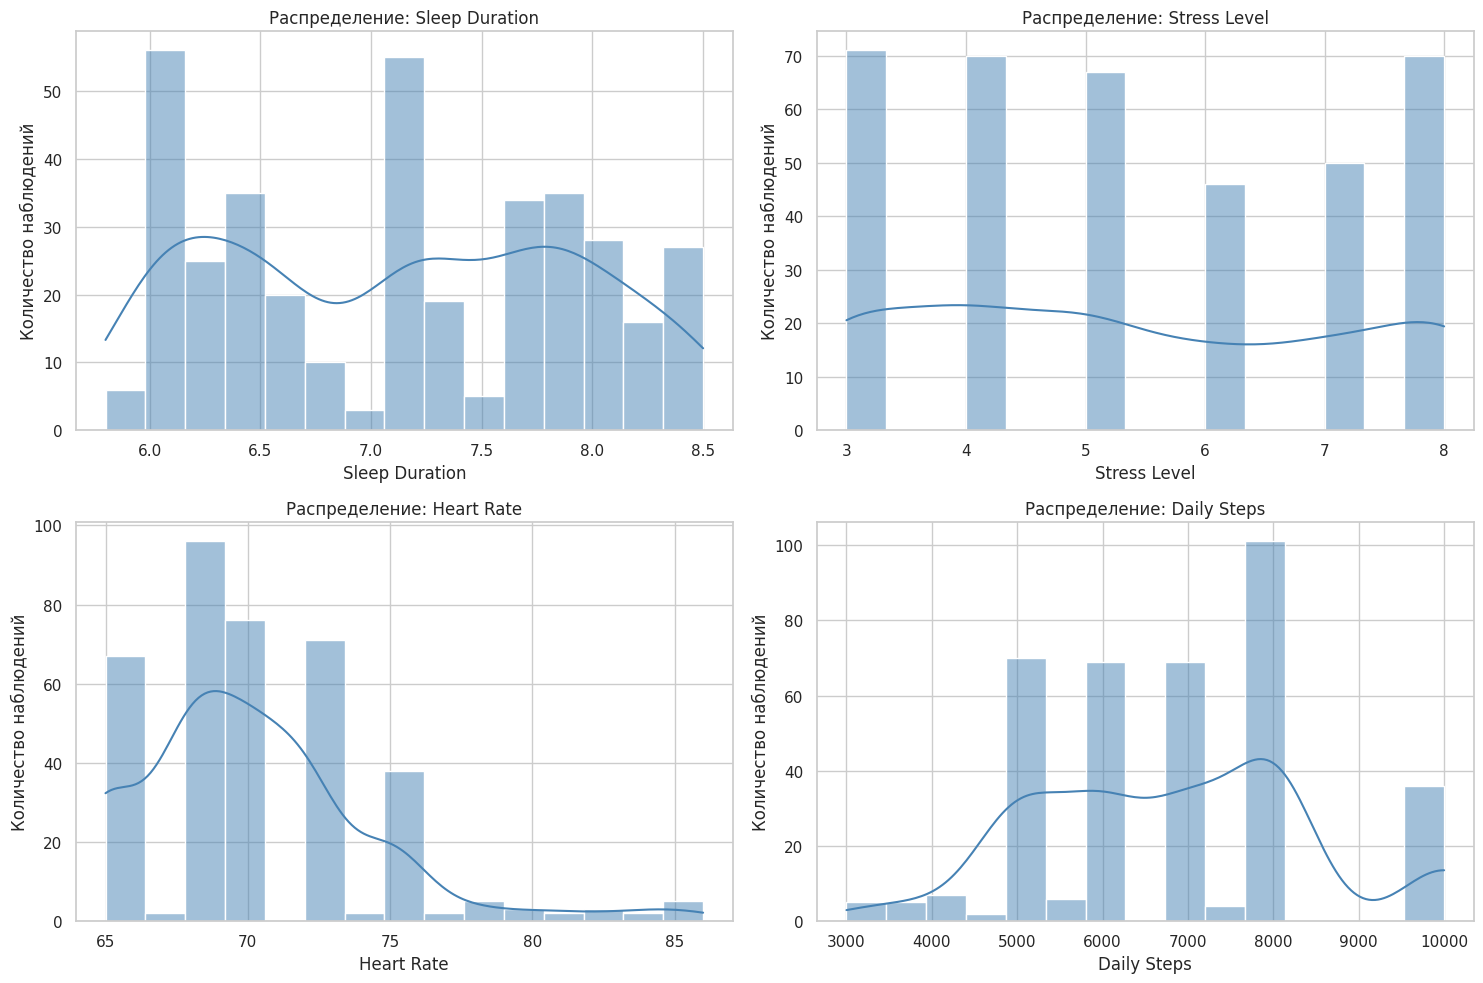

In [ ]:
# Ваш код здесь: гистограммы для числовых признаков
hist_columns = [
    'Sleep Duration',
    'Stress Level',
    'Heart Rate',
    'Daily Steps'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, column in zip(axes.ravel(), hist_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=15,
        color='steelblue',
        ax=ax
    )

    ax.set_title(f'Распределение: {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Количество наблюдений')

plt.tight_layout()
plt.show()

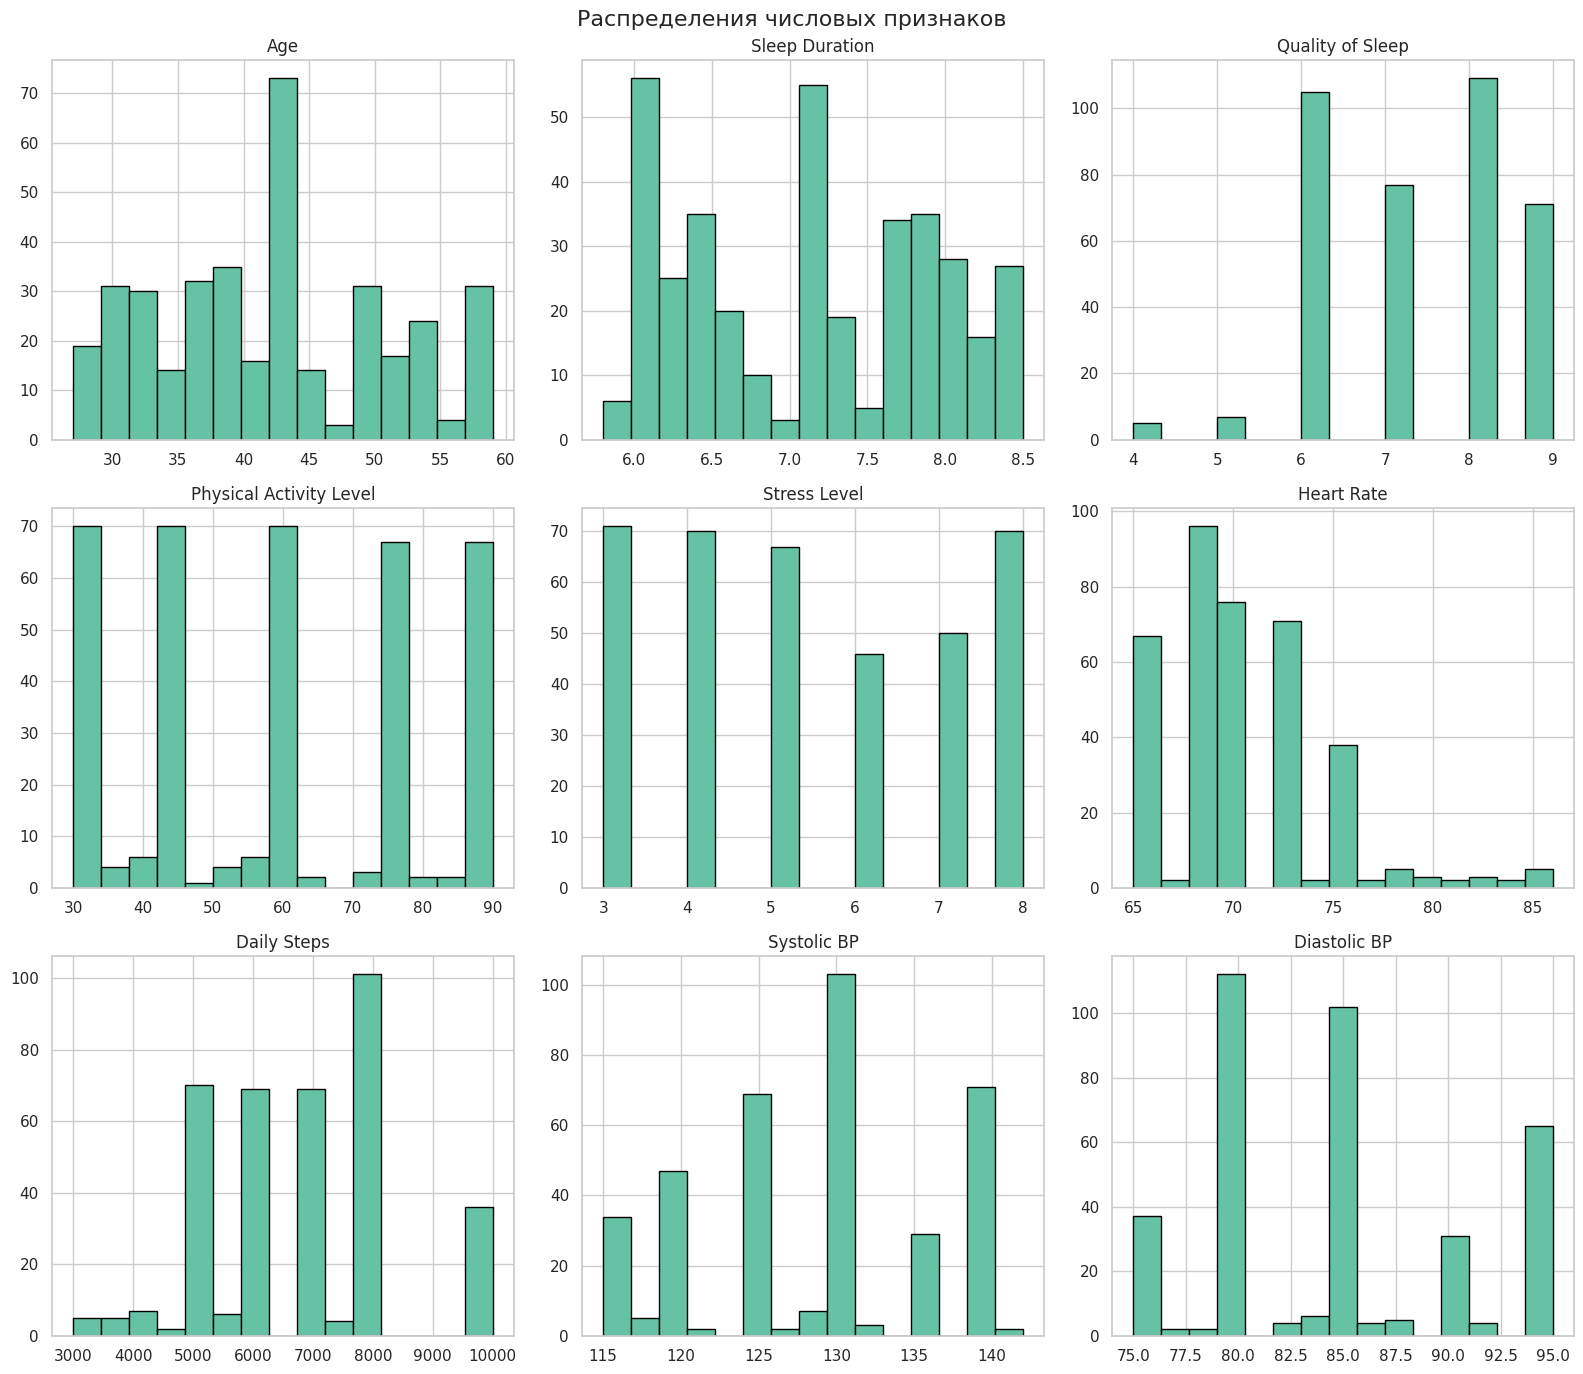

In [ ]:
df[numeric_columns].hist(
    bins=15,
    figsize=(16, 14),
    edgecolor='black'
)

plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

*Ваш вывод по распределениям числовых признаков:*
>

In [ ]:
print("""
Вывод по распределениям числовых признаков:

Гистограммы позволяют оценить форму распределений, их симметрию,
концентрацию значений и возможные экстремальные наблюдения.

Продолжительность сна в основном находится в диапазоне примерно
от 6 до 8 часов. Уровень стресса принимает дискретные значения,
так как измеряется по шкале от 1 до 10.

Распределения частоты сердечных сокращений и количества шагов могут
иметь несколько выраженных пиков. Это связано с тем, что в датасете
встречаются повторяющиеся группы людей с одинаковыми характеристиками.
""")


Вывод по распределениям числовых признаков:

Гистограммы позволяют оценить форму распределений, их симметрию,
концентрацию значений и возможные экстремальные наблюдения.

Продолжительность сна в основном находится в диапазоне примерно
от 6 до 8 часов. Уровень стресса принимает дискретные значения,
так как измеряется по шкале от 1 до 10.

Распределения частоты сердечных сокращений и количества шагов могут
иметь несколько выраженных пиков. Это связано с тем, что в датасете
встречаются повторяющиеся группы людей с одинаковыми характеристиками.



### Сравнение распределений и визуализация формы
Постройте boxplot для поиска выбросов и сравнения распределений, а также violin plot для визуального анализа формы распределений данных.

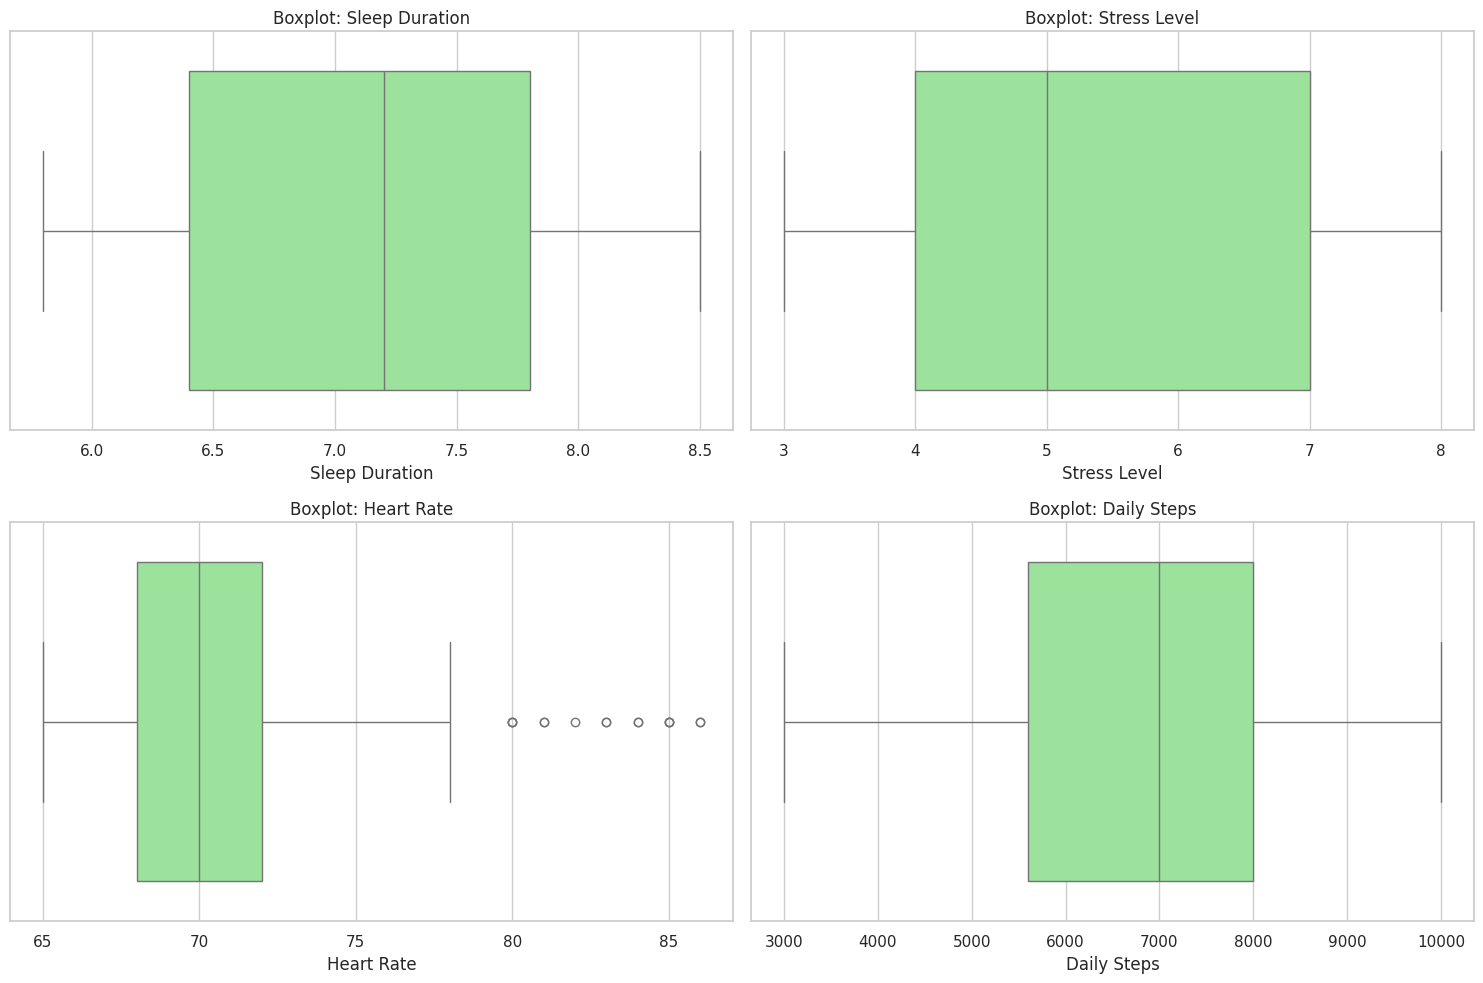

In [ ]:
# Ваш код здесь: постройте boxplot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, column in zip(axes.ravel(), hist_columns):
    sns.boxplot(
        data=df,
        x=column,
        color='lightgreen',
        ax=ax
    )

    ax.set_title(f'Boxplot: {column}')
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

Общий boxplot для числовых признаков
Так как признаки имеют разные единицы измерения, сначала стандартизируем их для корректного сравнения.


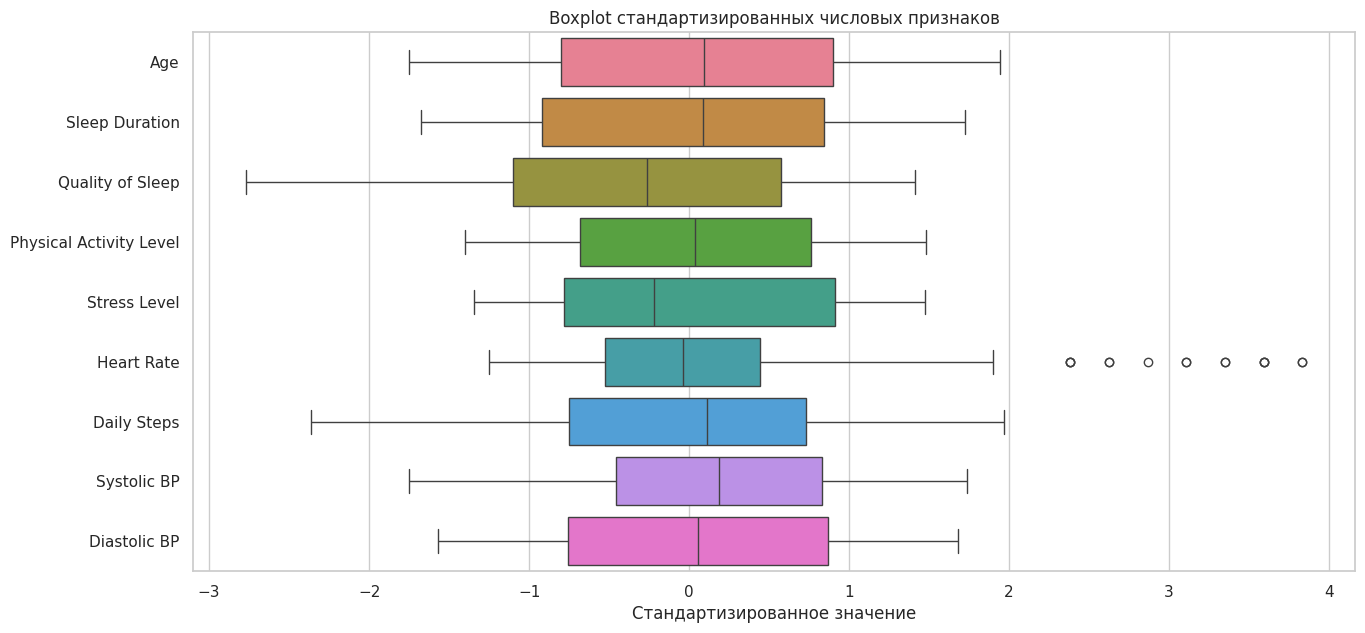

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_values = scaler.fit_transform(df[numeric_columns])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=numeric_columns
)

plt.figure(figsize=(15, 7))
sns.boxplot(data=scaled_df, orient='h')
plt.title('Boxplot стандартизированных числовых признаков')
plt.xlabel('Стандартизированное значение')
plt.show()

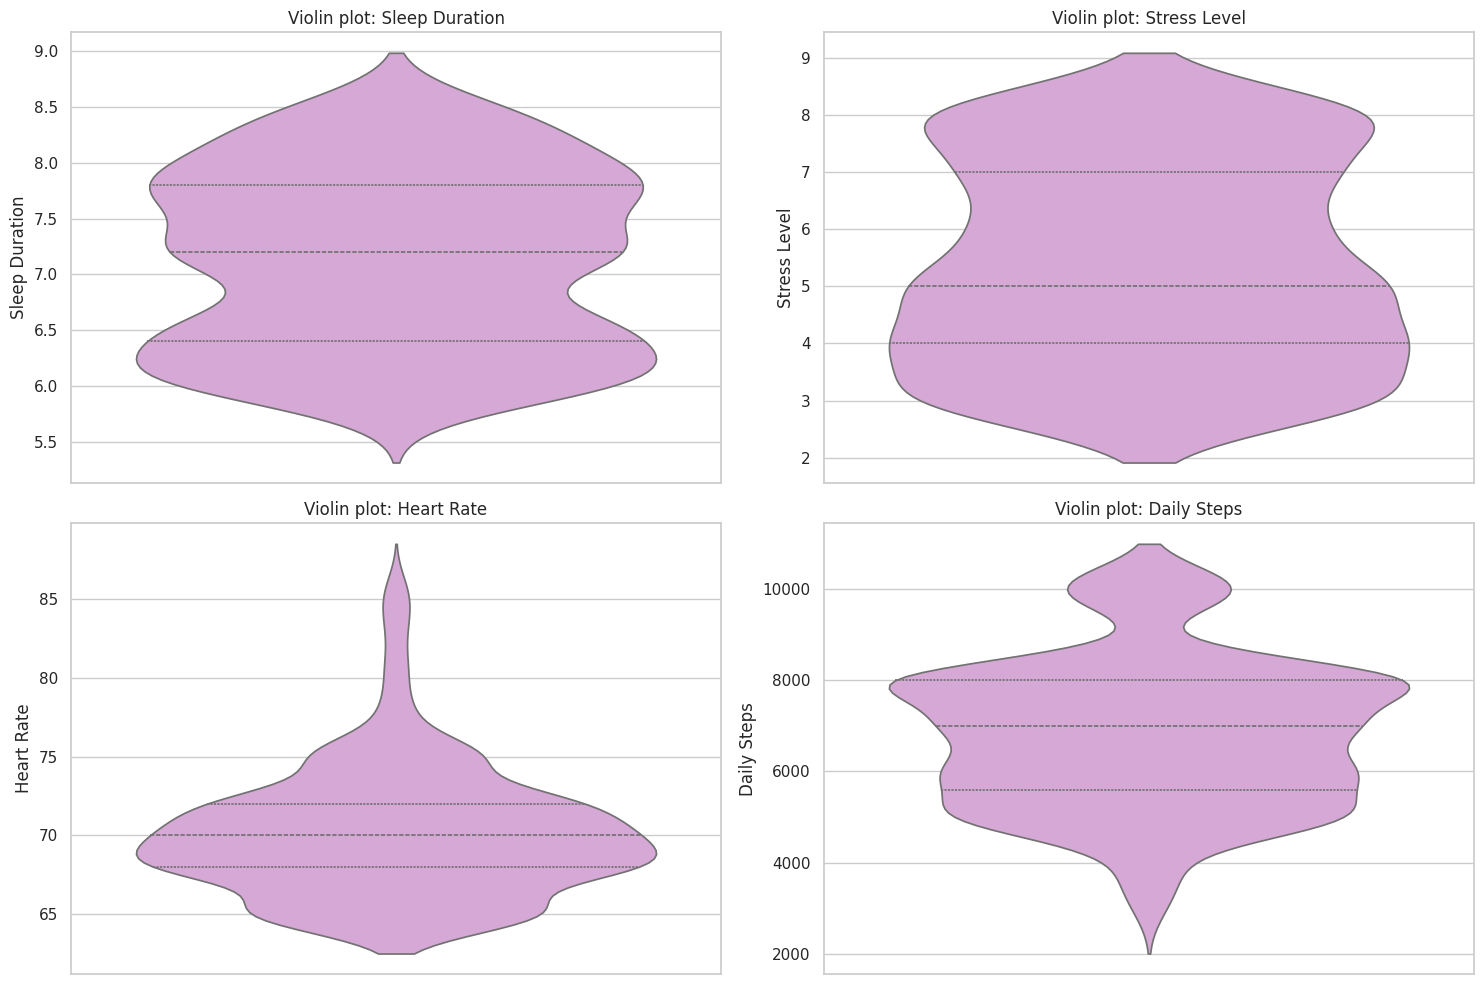

In [ ]:
# Ваш код здесь: постройте violin plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, column in zip(axes.ravel(), hist_columns):
    sns.violinplot(
        data=df,
        y=column,
        color='plum',
        inner='quartile',
        ax=ax
    )

    ax.set_title(f'Violin plot: {column}')
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

*Ваш вывод по boxplot и violin plot:*
>

In [ ]:
print("""
Вывод по boxplot и violin plot:

Boxplot показывает медиану, первый и третий квартили, межквартильный
размах и возможные выбросы. Violin plot дополнительно показывает форму
распределения и концентрацию значений.

Если ширина violin plot увеличивается в определённом диапазоне,
это означает, что в данном диапазоне находится больше наблюдений.
Повторяющиеся значения в некоторых признаках приводят к выраженным
локальным пикам распределения.

Выбросы, обнаруженные на графиках, необходимо дополнительно проверять
статистическими методами IQR и Z-score.
""")


Вывод по boxplot и violin plot:

Boxplot показывает медиану, первый и третий квартили, межквартильный
размах и возможные выбросы. Violin plot дополнительно показывает форму
распределения и концентрацию значений.

Если ширина violin plot увеличивается в определённом диапазоне,
это означает, что в данном диапазоне находится больше наблюдений.
Повторяющиеся значения в некоторых признаках приводят к выраженным
локальным пикам распределения.

Выбросы, обнаруженные на графиках, необходимо дополнительно проверять
статистическими методами IQR и Z-score.



## 6. Поиск выбросов
### Метод IQR
Найдите выбросы методом IQR для нескольких числовых признаков (например, Daily Steps, Sleep Duration, Heart Rate).

In [ ]:
# Ваш код здесь: расчёт выбросов по методу IQR
outlier_columns = [
    'Daily Steps',
    'Sleep Duration',
    'Heart Rate'
]

def find_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        'Признак': column,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Нижняя граница': lower_bound,
        'Верхняя граница': upper_bound,
        'Количество выбросов': len(outliers),
        'Индексы выбросов': list(outliers.index)
    }

iqr_results = pd.DataFrame(
    [find_iqr_outliers(df, column) for column in outlier_columns]
)

iqr_results.drop(columns='Индексы выбросов').round(2)

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Количество выбросов
0,Daily Steps,5600.00,8000.00,2400.00,2000.00,11600.00,0
1,Sleep Duration,6.40,7.80,1.40,4.30,9.90,0
2,Heart Rate,68.00,72.00,4.00,62.00,78.00,15


Просмотр строк, определённых как выбросы методом IQR

In [ ]:
for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f'\nПризнак: {column}')
    print(f'Количество выбросов: {len(outliers)}')
    display(outliers[['Person ID', column]])


Признак: Daily Steps
Количество выбросов: 0


,Person ID,Daily Steps



Признак: Sleep Duration
Количество выбросов: 0


,Person ID,Sleep Duration



Признак: Heart Rate
Количество выбросов: 15


,Person ID,Heart Rate
3,4,85
4,5,85
5,6,85
6,7,82
16,17,80
18,19,80
80,81,81
81,82,81
93,94,84
145,146,84


### Метод Z-score
Найдите выбросы методом Z-score для тех же признаков. Сравните результаты двух методов.

In [ ]:
# Ваш код здесь: расчёт выбросов по методу Z-score
zscore_results = []

for column in outlier_columns:
    z_scores = np.abs(stats.zscore(df[column], nan_policy='omit'))

    outlier_mask = z_scores > 3
    outliers = df[outlier_mask]

    zscore_results.append({
        'Признак': column,
        'Порог Z-score': 3,
        'Количество выбросов': outlier_mask.sum(),
        'Минимальный Z-score': z_scores.min(),
        'Максимальный Z-score': z_scores.max()
    })

zscore_results = pd.DataFrame(zscore_results)
zscore_results.round(2)

,Признак,Порог Z-score,Количество выбросов,Минимальный Z-score,Максимальный Z-score
0,Daily Steps,3,0,0.01,2.36
1,Sleep Duration,3,0,0.04,1.72
2,Heart Rate,3,9,0.04,3.83


Сравнение методов IQR и Z-score

In [ ]:
comparison = []

for column in outlier_columns:
    # IQR
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    # Z-score
    z_scores = np.abs(stats.zscore(df[column], nan_policy='omit'))
    zscore_mask = z_scores > 3

    comparison.append({
        'Признак': column,
        'Выбросы IQR': iqr_mask.sum(),
        'Выбросы Z-score': zscore_mask.sum(),
        'Общие выбросы': (iqr_mask & zscore_mask).sum(),
        'Только IQR': (iqr_mask & ~zscore_mask).sum(),
        'Только Z-score': (~iqr_mask & zscore_mask).sum()
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Признак,Выбросы IQR,Выбросы Z-score,Общие выбросы,Только IQR,Только Z-score
0,Daily Steps,0,0,0,0,0
1,Sleep Duration,0,0,0,0,0
2,Heart Rate,15,9,9,6,0


*Ваш вывод и сравнение результатов IQR и Z-score:*
>

In [ ]:
print("""
Вывод и сравнение результатов IQR и Z-score:

Метод IQR основан на квартилях и межквартильном размахе. Он устойчив
к асимметрии распределения и часто выявляет больше потенциальных выбросов.

Метод Z-score использует среднее значение и стандартное отклонение.
Он лучше подходит для приблизительно нормальных распределений, но может
быть менее устойчив к уже существующим экстремальным значениям.

Выброс не обязательно является ошибкой. В медицинском или социальном
датасете он может представлять реального человека с необычными показателями.
Поэтому удалять такие строки автоматически не следует.
""")


Вывод и сравнение результатов IQR и Z-score:

Метод IQR основан на квартилях и межквартильном размахе. Он устойчив
к асимметрии распределения и часто выявляет больше потенциальных выбросов.

Метод Z-score использует среднее значение и стандартное отклонение.
Он лучше подходит для приблизительно нормальных распределений, но может
быть менее устойчив к уже существующим экстремальным значениям.

Выброс не обязательно является ошибкой. В медицинском или социальном
датасете он может представлять реального человека с необычными показателями.
Поэтому удалять такие строки автоматически не следует.



## 7. Категориальный анализ
Выполните группировку данных по категориальным признакам с помощью `groupby()`. Постройте countplot и pie chart для анализа категориальных признаков.

Распределение пола

Распределение по полу:


,Количество
Gender,
Male,189
Female,185


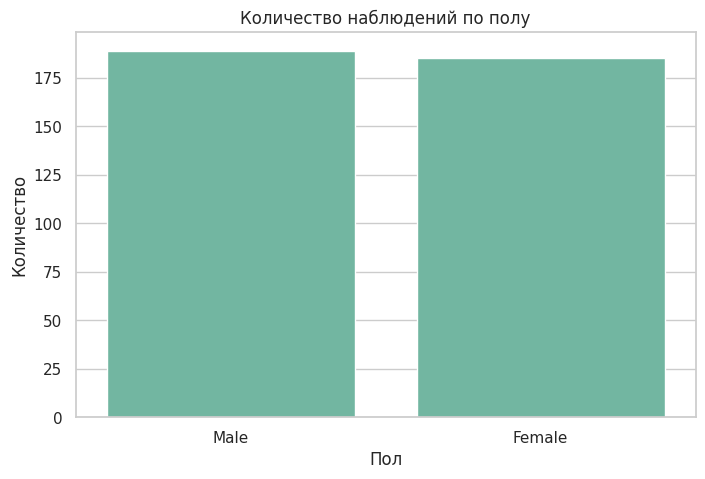

In [ ]:
gender_counts = df['Gender'].value_counts()

print('Распределение по полу:')
display(gender_counts.to_frame('Количество'))

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Gender',
    order=gender_counts.index
)

plt.title('Количество наблюдений по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

Распределение нарушений сна

Распределение нарушений сна:


,Количество
Sleep Disorder,
Sleep Apnea,78
Insomnia,77


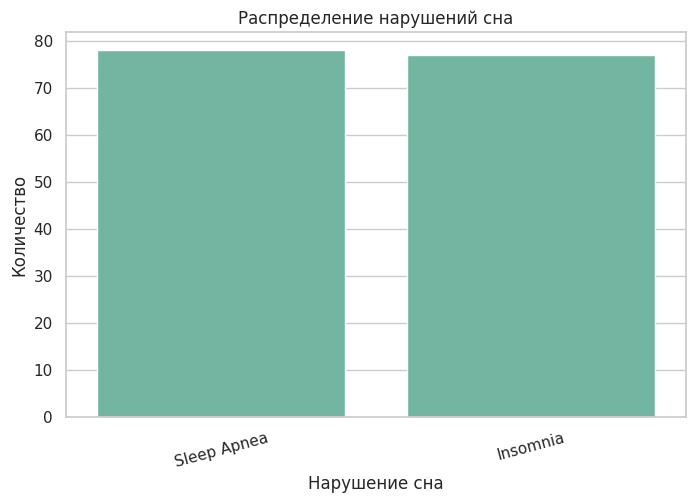

In [ ]:
sleep_disorder_counts = df['Sleep Disorder'].value_counts()

print('Распределение нарушений сна:')
display(sleep_disorder_counts.to_frame('Количество'))

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Sleep Disorder',
    order=sleep_disorder_counts.index
)

plt.title('Распределение нарушений сна')
plt.xlabel('Нарушение сна')
plt.ylabel('Количество')
plt.xticks(rotation=15)
plt.show()

Круговая диаграмма нарушений сна

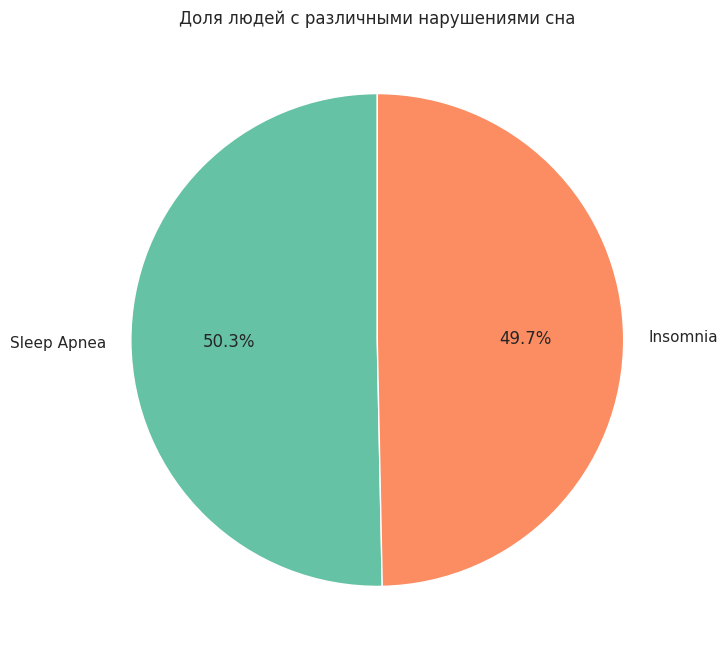

In [ ]:
plt.figure(figsize=(8, 8))

plt.pie(
    sleep_disorder_counts.values,
    labels=sleep_disorder_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Доля людей с различными нарушениями сна')
plt.show()

Распределение категорий BMI

Распределение категорий BMI:


,Количество
BMI Category,
Normal,195
Overweight,148
Normal Weight,21
Obese,10


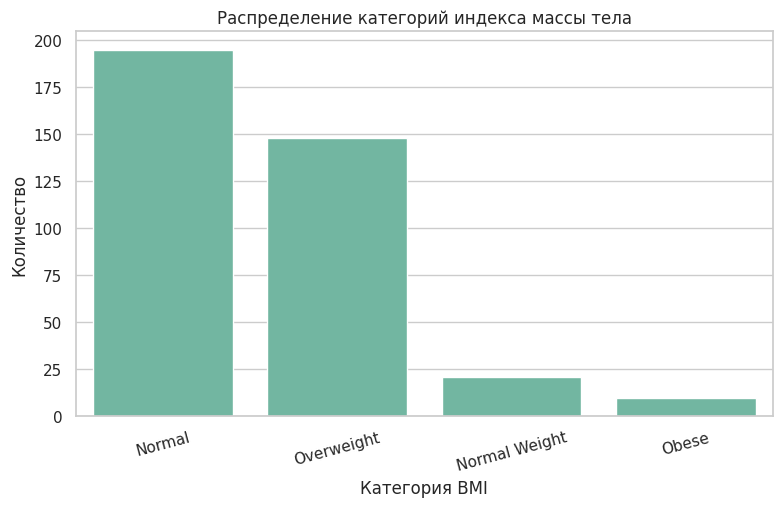

In [ ]:
bmi_counts = df['BMI Category'].value_counts()

print('Распределение категорий BMI:')
display(bmi_counts.to_frame('Количество'))

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x='BMI Category',
    order=bmi_counts.index
)

plt.title('Распределение категорий индекса массы тела')
plt.xlabel('Категория BMI')
plt.ylabel('Количество')
plt.xticks(rotation=15)
plt.show()

In [ ]:
Группировка по нарушениям сна

In [ ]:
grouped_sleep_disorder = (
    df.groupby('Sleep Disorder')
      .agg(
          Количество=('Person ID', 'count'),
          Средний_возраст=('Age', 'mean'),
          Средняя_продолжительность_сна=('Sleep Duration', 'mean'),
          Среднее_качество_сна=('Quality of Sleep', 'mean'),
          Средний_уровень_стресса=('Stress Level', 'mean'),
          Средний_пульс=('Heart Rate', 'mean'),
          Среднее_количество_шагов=('Daily Steps', 'mean')
      )
      .sort_values('Количество', ascending=False)
)

grouped_sleep_disorder.round(2)

,Количество,Средний_возраст,Средняя_продолжительность_сна,Среднее_качество_сна,Средний_уровень_стресса,Средний_пульс,Среднее_количество_шагов
Sleep Disorder,,,,,,,
Sleep Apnea,78,49.71,7.03,7.21,5.67,73.09,7619.23
Insomnia,77,43.52,6.59,6.53,5.87,70.47,5901.30


Группировка по полу

In [ ]:
grouped_gender = (
    df.groupby('Gender')
      .agg(
          Количество=('Person ID', 'count'),
          Средний_возраст=('Age', 'mean'),
          Средняя_продолжительность_сна=('Sleep Duration', 'mean'),
          Среднее_качество_сна=('Quality of Sleep', 'mean'),
          Средний_уровень_стресса=('Stress Level', 'mean'),
          Средняя_физическая_активность=('Physical Activity Level', 'mean'),
          Средний_пульс=('Heart Rate', 'mean')
      )
)

grouped_gender.round(2)

,Количество,Средний_возраст,Средняя_продолжительность_сна,Среднее_качество_сна,Средний_уровень_стресса,Средняя_физическая_активность,Средний_пульс
Gender,,,,,,,
Female,185,47.41,7.23,7.66,4.68,59.14,69.26
Male,189,37.07,7.04,6.97,6.08,59.20,71.05


Сравнение продолжительности сна по нарушениям

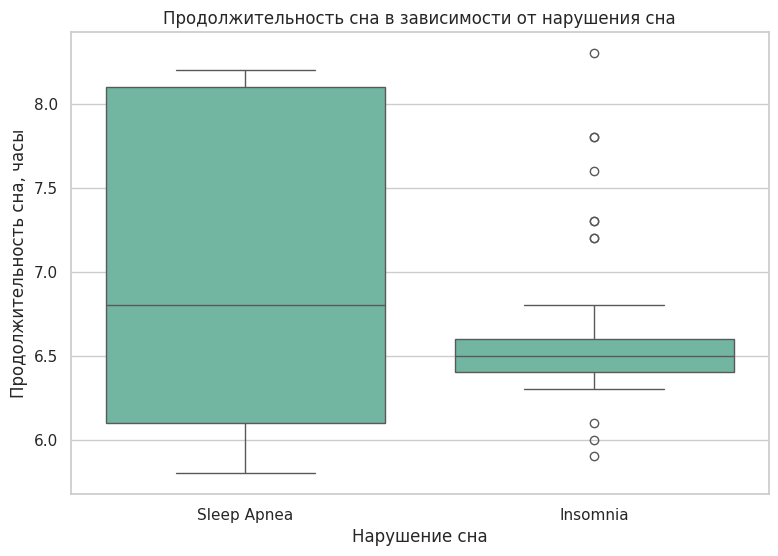

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Sleep Disorder',
    y='Sleep Duration',
    order=df['Sleep Disorder'].value_counts().index
)

plt.title('Продолжительность сна в зависимости от нарушения сна')
plt.xlabel('Нарушение сна')
plt.ylabel('Продолжительность сна, часы')
plt.show()

Сравнение стресса по нарушениям сна

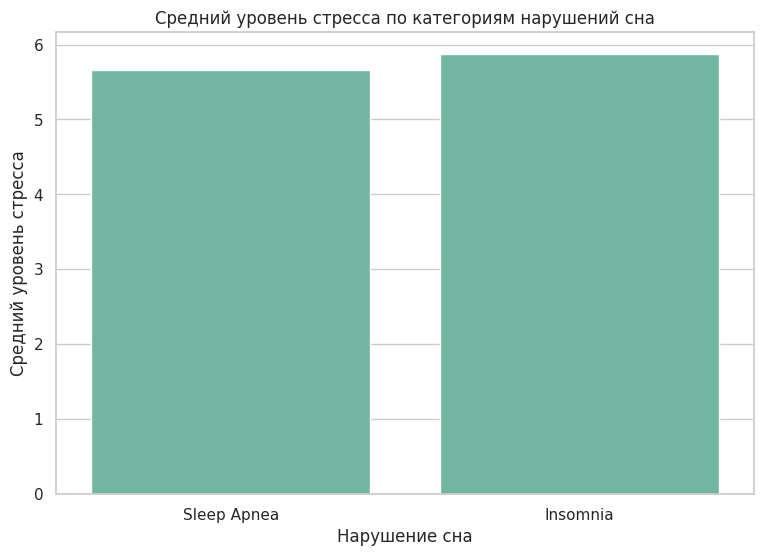

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x='Sleep Disorder',
    y='Stress Level',
    estimator='mean',
    errorbar=None,
    order=df['Sleep Disorder'].value_counts().index
)

plt.title('Средний уровень стресса по категориям нарушений сна')
plt.xlabel('Нарушение сна')
plt.ylabel('Средний уровень стресса')
plt.show()

*Ваш вывод по категориальному анализу:*
>

In [ ]:
print("""
Вывод по категориальному анализу:

Наиболее часто встречается категория отсутствия нарушения сна — None.
Также в датасете представлены группы людей с бессонницей и апноэ сна.

Группировка показывает, что категории нарушений сна отличаются
по продолжительности и качеству сна, уровню стресса, физической активности
и другим показателям здоровья.

При интерпретации результатов необходимо учитывать, что датасет содержит
повторяющиеся комбинации признаков. Поэтому полученные зависимости
не следует автоматически трактовать как причинно-следственные.
""")


Вывод по категориальному анализу:

Наиболее часто встречается категория отсутствия нарушения сна — None.
Также в датасете представлены группы людей с бессонницей и апноэ сна.

Группировка показывает, что категории нарушений сна отличаются
по продолжительности и качеству сна, уровню стресса, физической активности
и другим показателям здоровья.

При интерпретации результатов необходимо учитывать, что датасет содержит
повторяющиеся комбинации признаков. Поэтому полученные зависимости
не следует автоматически трактовать как причинно-следственные.



10. Дополнительная корреляционная матрица

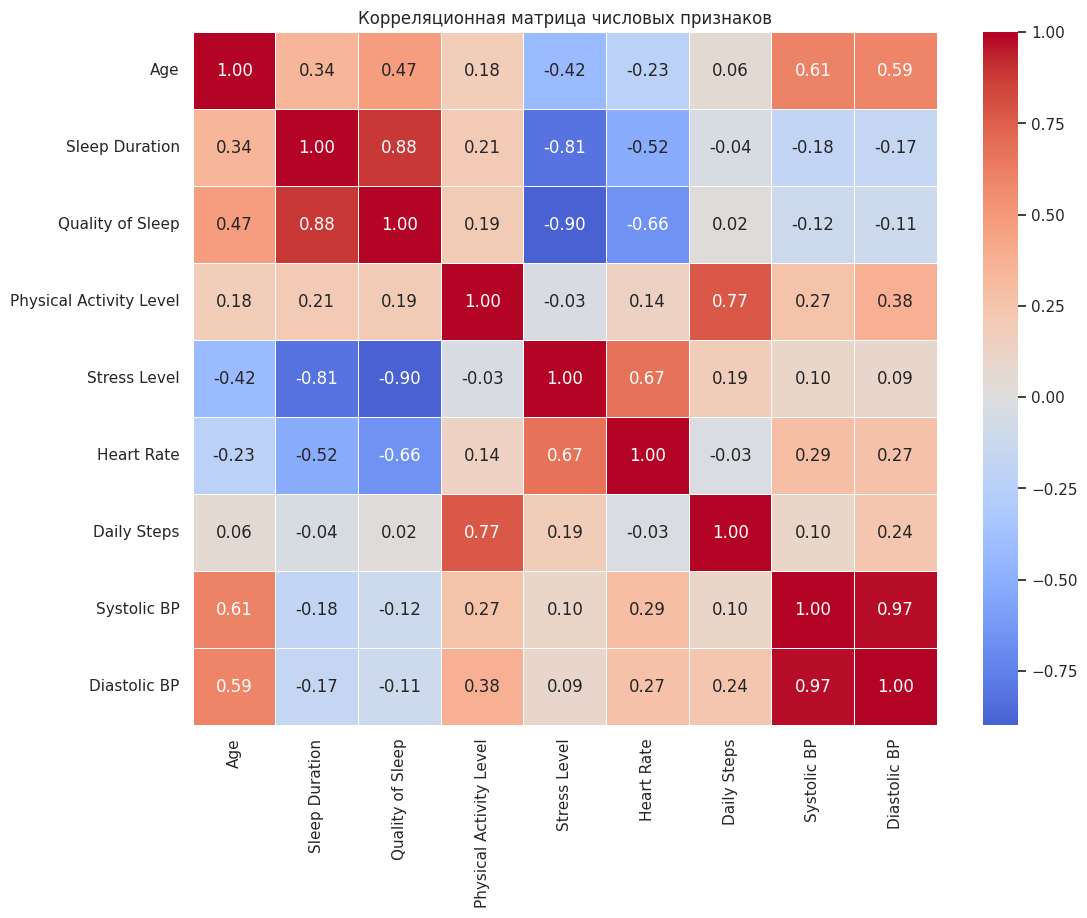

In [ ]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Корреляционная матрица числовых признаков')
plt.show()

Самые сильные корреляции

In [ ]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=np.abs, ascending=False)
)

corr_pairs.head(10)

Systolic BP              Diastolic BP        0.97
Quality of Sleep         Stress Level       -0.90
Sleep Duration           Quality of Sleep    0.88
                         Stress Level       -0.81
Physical Activity Level  Daily Steps         0.77
Stress Level             Heart Rate          0.67
Quality of Sleep         Heart Rate         -0.66
Age                      Systolic BP         0.61
                         Diastolic BP        0.59
Sleep Duration           Heart Rate         -0.52
dtype: float64

## 8. Итоговый вывод
Сформулируйте общий вывод по датасету на основе проведённого анализа.

*Ваш итоговый вывод:*
>В результате анализа датасета Sleep Health and Lifestyle Dataset было установлено,
что данные не содержат значительного количества пропусков, а числовые признаки
имеют различный масштаб и форму распределения. Продолжительность и качество сна
связаны с уровнем стресса, физической активностью и наличием нарушений сна.

Наиболее распространённой категорией является отсутствие нарушения сна. Среди
нарушений сна встречаются бессонница и апноэ сна. Boxplot и violin plot позволяют
обнаружить особенности формы распределений и потенциальные выбросы.

Метод IQR является более устойчивым к асимметрии распределений, тогда как метод
Z-score лучше работает для данных, близких к нормальному распределению. Выявленные
выбросы не следует удалять без дополнительной проверки, поскольку они могут быть
реальными значениями.

В целом датасет позволяет провести описательный анализ сна, образа жизни и
показателей здоровья, но обнаруженные зависимости следует рассматривать как
статистические связи, а не как доказанные причинно-следственные зависимости.


In [ ]:
print("""
Итоговый вывод:

В ходе анализа был изучен датасет Sleep Health and Lifestyle Dataset,
содержащий сведения о 374 людях и 13 исходных признаках.

Были выполнены:
- первичный анализ структуры данных;
- проверка типов данных, пропусков и дубликатов;
- расчёт среднего, медианы и стандартного отклонения;
- построение гистограмм, boxplot и violin plot;
- поиск потенциальных выбросов методами IQR и Z-score;
- анализ категориальных признаков;
- группировка данных по полу, категории BMI и нарушению сна;
- построение корреляционной матрицы.

Основные наблюдения:

1. Продолжительность сна, качество сна, уровень стресса и физическая
   активность связаны с общей характеристикой образа жизни человека.

2. В датасете представлены три категории состояния сна:
   отсутствие нарушения, бессонница и апноэ сна.

3. Люди с разными нарушениями сна имеют различающиеся значения
   продолжительности сна, качества сна и уровня стресса.

4. Некоторые числовые признаки имеют дискретные значения и повторяющиеся
   группы наблюдений, поэтому на графиках могут появляться несколько пиков.

5. Выбросы, найденные статистическими методами, не следует автоматически
   удалять: они могут отражать реальные особенности здоровья людей.

6. Корреляционный анализ позволяет выявить взаимосвязи между признаками,
   однако корреляция не доказывает наличие причинно-следственной связи.
""")


Итоговый вывод:

В ходе анализа был изучен датасет Sleep Health and Lifestyle Dataset,
содержащий сведения о 374 людях и 13 исходных признаках.

Были выполнены:
- первичный анализ структуры данных;
- проверка типов данных, пропусков и дубликатов;
- расчёт среднего, медианы и стандартного отклонения;
- построение гистограмм, boxplot и violin plot;
- поиск потенциальных выбросов методами IQR и Z-score;
- анализ категориальных признаков;
- группировка данных по полу, категории BMI и нарушению сна;
- построение корреляционной матрицы.

Основные наблюдения:

1. Продолжительность сна, качество сна, уровень стресса и физическая
   активность связаны с общей характеристикой образа жизни человека.

2. В датасете представлены три категории состояния сна:
   отсутствие нарушения, бессонница и апноэ сна.

3. Люди с разными нарушениями сна имеют различающиеся значения
   продолжительности сна, качества сна и уровня стресса.

4. Некоторые числовые признаки имеют дискретные значения и повторяющиеся
